In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Target Distribution

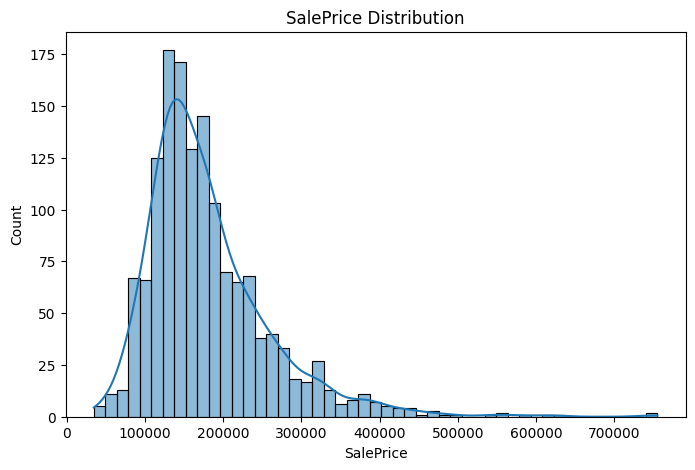

In [3]:
plt.figure(figsize=(8,5))

sns.histplot(df['SalePrice'],
             kde=True)

plt.title("SalePrice Distribution")

plt.show()

Skewness

In [4]:
print(df['SalePrice'].skew())

1.8828757597682129


QQ Plot

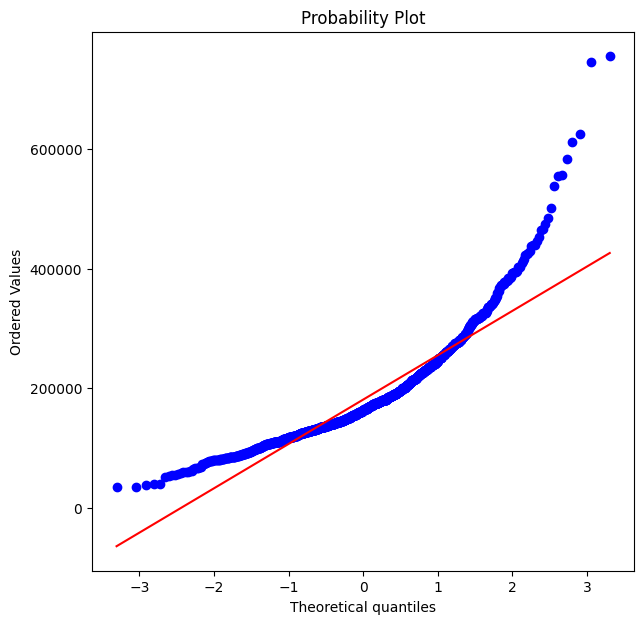

In [5]:
from scipy import stats

plt.figure(figsize=(7,7))

stats.probplot(df['SalePrice'],dist="norm",plot=plt)

plt.show()

In [6]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\red\AppData\Local\Temp\ipykernel_14212\3929094584.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns
C:\Users\red\AppData\Local\Temp\ipykernel_14212\3929094584.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[

In [7]:
if 'Id' in df.columns:
    df.drop('Id', axis=1, inplace=True)

# Label Encoding

In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

# Split Features and Target

In [9]:
X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]

# Train Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)

X_test_scaled=scaler.transform(X_test)

# Convert to DataFrame

In [12]:
X_train_scaled=pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled=pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

In [13]:
X_train_scaled.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,-0.866764,-0.054796,-0.013818,-0.212896,0.058621,0.247840,0.765535,0.299798,-0.029273,0.630128,...,-0.275838,-0.070993,0.066503,0.467615,0.197298,-0.09274,-0.133417,1.650065,0.316662,0.201772
1,0.074110,-0.054796,-0.455871,-0.265245,0.058621,0.247840,-1.356644,0.299798,-0.029273,0.630128,...,-0.275838,-0.070993,0.066503,0.467615,0.197298,-0.09274,-0.508010,0.893677,0.316662,0.201772
2,-0.631546,-0.054796,-0.134378,-0.177841,0.058621,0.247840,0.765535,0.299798,-0.029273,0.630128,...,-0.275838,-0.070993,0.066503,-1.343907,0.197298,-0.09274,-0.508010,0.137290,0.316662,0.201772
3,-0.161109,-0.054796,-0.415684,-0.324474,0.058621,0.247840,0.765535,0.299798,-0.029273,-1.792884,...,-0.275838,-0.070993,0.066503,-1.343907,0.197298,-0.09274,-0.133417,-0.619098,0.316662,0.201772
4,-0.161109,-0.054796,-0.817550,-0.529035,0.058621,-2.205357,0.765535,0.299798,-0.029273,0.630128,...,-0.275838,-0.070993,0.066503,0.467615,0.197298,-0.09274,-0.508010,1.650065,0.316662,0.201772


# Model Evaluation

In [34]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

def evaluate(model):

    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test,prediction)

    mse = mean_squared_error(y_test,prediction)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test,prediction)

    print("MAE :",mae)
    print("MSE :",mse)
    print("RMSE :",rmse)
    print("R2 Score :",r2)

    return mae,mse,rmse,r2

# Linear Regression

In [16]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [17]:
from sklearn.linear_model import LinearRegression

linear = LinearRegression()

linear.fit(X_train,y_train)

linear_result = evaluate(linear)

MAE : 21536.38927137496
MSE : 1192159335.3870528
RMSE : 34527.6604389445
R2 Score : 0.844575145412982


# Ridge Regression

In [19]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train,y_train)

ridge_result = evaluate(ridge)

MAE : 21451.197803788426
MSE : 1180063608.3916974
RMSE : 34352.053918094876
R2 Score : 0.8461520962060293


# Lasso Regression

In [20]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=100)

lasso.fit(X_train,y_train)

lasso_result = evaluate(lasso)

MAE : 21370.738913051766
MSE : 1176792351.13727
RMSE : 34304.40716784463
R2 Score : 0.8465785783615551


C:\Users\red\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.903e+10, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


# Decision Tree Regression

In [21]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train,y_train)

tree_result = evaluate(tree)

MAE : 27676.81506849315
MSE : 1734082451.910959
RMSE : 41642.315640595196
R2 Score : 0.7739232458867111


# Random Forest Regression

In [22]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

forest.fit(X_train,y_train)

forest_result = evaluate(forest)

MAE : 17499.91585616438
MSE : 819933557.265938
RMSE : 28634.481962590802
R2 Score : 0.8931031699150348


# Gradient Boosting Regression

In [23]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train,y_train)

gb_result = evaluate(gb)

MAE : 17349.503218290276
MSE : 836840848.7169458
RMSE : 28928.201615671613
R2 Score : 0.8908989231862365


# Compare Models

In [24]:
comparison = pd.DataFrame({

"Model":[
"Linear Regression",
"Ridge",
"Lasso",
"Decision Tree",
"Random Forest",
"Gradient Boosting"
],

"MAE":[
linear_result[0],
ridge_result[0],
lasso_result[0],
tree_result[0],
forest_result[0],
gb_result[0]
],

"RMSE":[
linear_result[2],
ridge_result[2],
lasso_result[2],
tree_result[2],
forest_result[2],
gb_result[2]
],

"R2 Score":[
linear_result[3],
ridge_result[3],
lasso_result[3],
tree_result[3],
forest_result[3],
gb_result[3]
]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,21536.389271,34527.660439,0.844575
1,Ridge,21451.197804,34352.053918,0.846152
2,Lasso,21370.738913,34304.407168,0.846579
3,Decision Tree,27676.815068,41642.315641,0.773923
4,Random Forest,17499.915856,28634.481963,0.893103
5,Gradient Boosting,17349.503218,28928.201616,0.890899


Best Model

In [25]:
comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
4,Random Forest,17499.915856,28634.481963,0.893103
5,Gradient Boosting,17349.503218,28928.201616,0.890899
2,Lasso,21370.738913,34304.407168,0.846579
1,Ridge,21451.197804,34352.053918,0.846152
0,Linear Regression,21536.389271,34527.660439,0.844575
3,Decision Tree,27676.815068,41642.315641,0.773923


# Cross Validation (Random Forest)

In [26]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(

    forest,

    X,

    y,

    cv=5,

    scoring='r2'

)

print(scores)

print("Average Score :",scores.mean())

[0.87589356 0.85082796 0.87241821 0.88090515 0.81015662]
Average Score : 0.858040301878965


# Hyperparameter Tuning

In [27]:
from sklearn.model_selection import GridSearchCV

parameters = {

'n_estimators':[100,200],

'max_depth':[10,20,None],

'min_samples_split':[2,5]

}

grid = GridSearchCV(

RandomForestRegressor(random_state=42),

parameters,

cv=3,

scoring='r2',

n_jobs=-1

)

grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sco

Best Parameters

In [28]:
print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


Best Model

In [29]:
best_model = grid.best_estimator_

prediction = best_model.predict(X_test)

print("R2 Score :",r2_score(y_test,prediction))

print("RMSE :",np.sqrt(mean_squared_error(y_test,prediction)))

R2 Score : 0.8931031699150348
RMSE : 28634.481962590802


Feature Importance

In [30]:
importance = pd.DataFrame({

'Feature':X.columns,

'Importance':best_model.feature_importances_

})

importance = importance.sort_values(

by='Importance',

ascending=False

)

importance.head(20)

,Feature,Importance
16,OverallQual,0.554742
45,GrLivArea,0.122667
37,TotalBsmtSF,0.033974
43,2ndFlrSF,0.031620
42,1stFlrSF,0.028130
33,BsmtFinSF1,0.027032
3,LotArea,0.017991
61,GarageArea,0.015169
60,GarageCars,0.014218
18,YearBuilt,0.012139


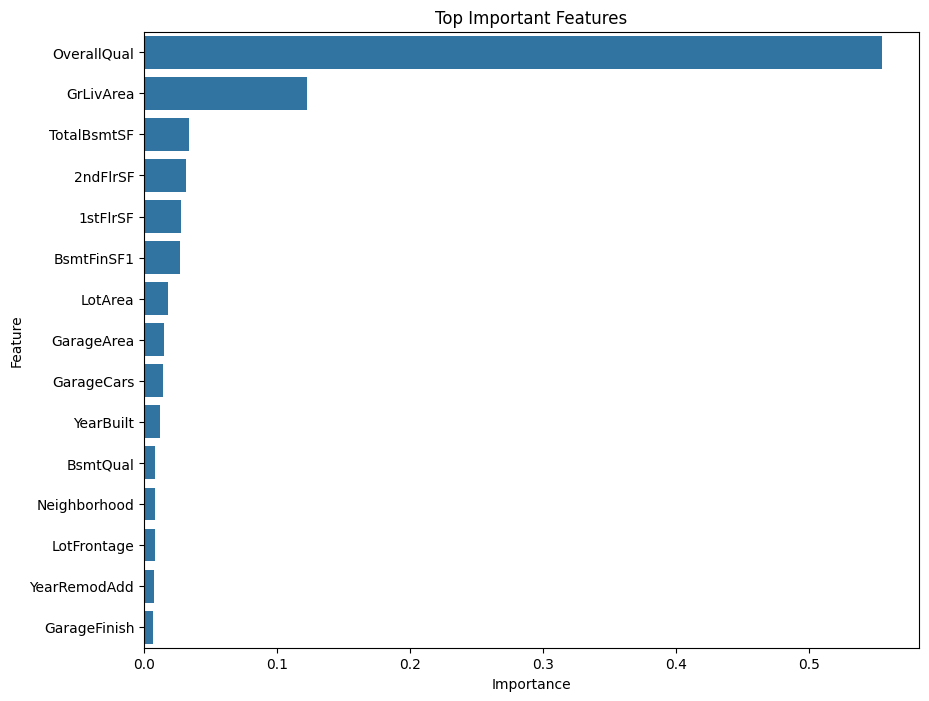

In [31]:
plt.figure(figsize=(10,8))

sns.barplot(

x='Importance',

y='Feature',

data=importance.head(15)

)

plt.title("Top Important Features")

plt.show()

In [35]:
mae = mean_absolute_error(y_test, prediction)

mse = mean_squared_error(y_test, prediction)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, prediction)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 17499.91585616438
MSE : 819933557.265938
RMSE : 28634.481962590802
R2 Score : 0.8931031699150348


Evaluation Summary Table

In [36]:
result = pd.DataFrame({

"Metric":[
"Mean Absolute Error",
"Mean Squared Error",
"Root Mean Squared Error",
"R2 Score"
],

"Value":[
mae,
mse,
rmse,
r2
]

})

result

,Metric,Value
0,Mean Absolute Error,1.749992e+04
1,Mean Squared Error,8.199336e+08
2,Root Mean Squared Error,2.863448e+04
3,R2 Score,8.931032e-01


# Actual vs Predicted

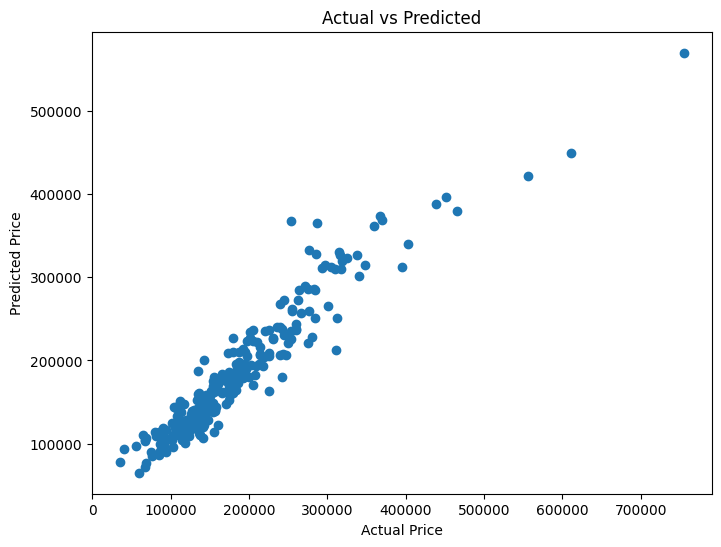

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, prediction)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()


Regression Line Plot

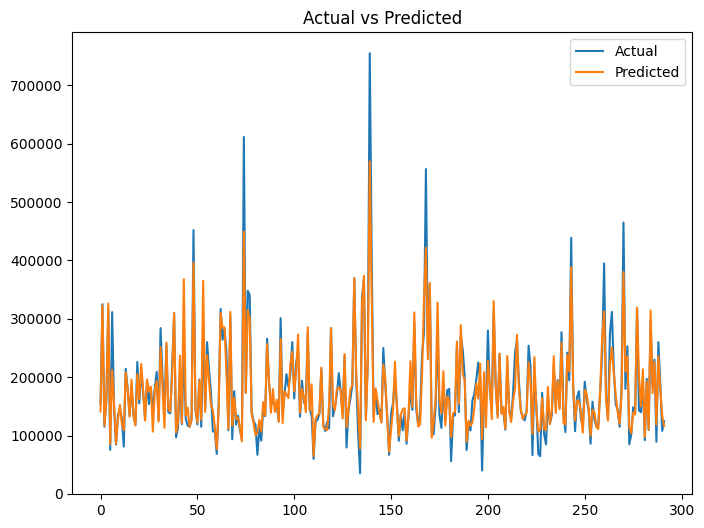

In [38]:
plt.figure(figsize=(8,6))

plt.plot(y_test.values, label="Actual")

plt.plot(prediction, label="Predicted")

plt.legend()

plt.title("Actual vs Predicted")

plt.show()

Residual Error

In [39]:
residual = y_test - prediction

residual.head()

892     13203.625
1105     2230.430
413     -1709.500
522     -4858.150
1036   -10627.660
Name: SalePrice, dtype: float64

Residual Distribution

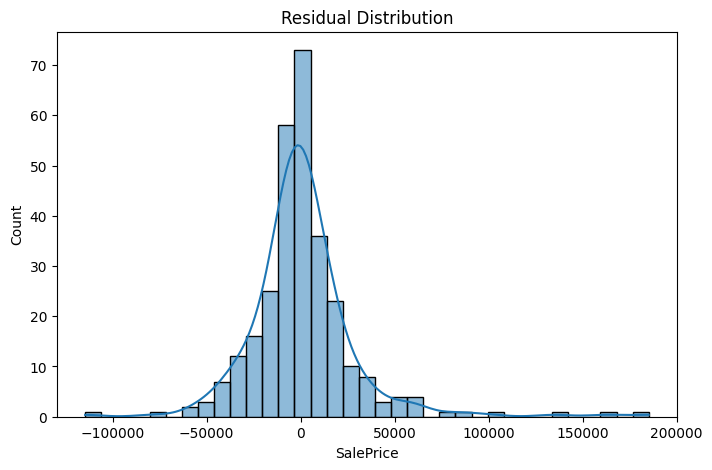

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(residual, kde=True)

plt.title("Residual Distribution")

plt.show()

Residual Scatter Plot

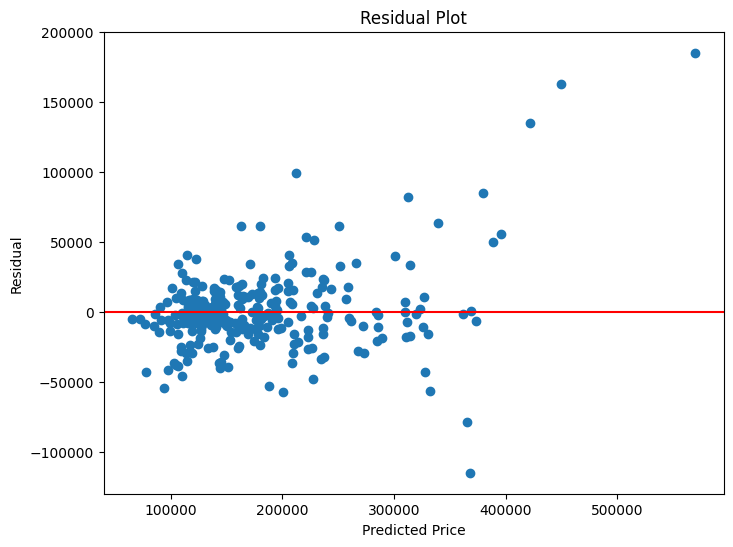

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(prediction, residual)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [42]:
compare = pd.DataFrame({

"Actual":y_test.values,

"Predicted":prediction

})

compare.head(20)

,Actual,Predicted
0,154500,141296.375
1,325000,322769.570
2,115000,116709.500
3,159000,163858.150
4,315500,326127.660
5,75500,85283.830
6,311500,212006.465
7,146000,153169.700
8,84500,86061.910
9,135500,127677.355


Actual vs Predicted Bar Chart

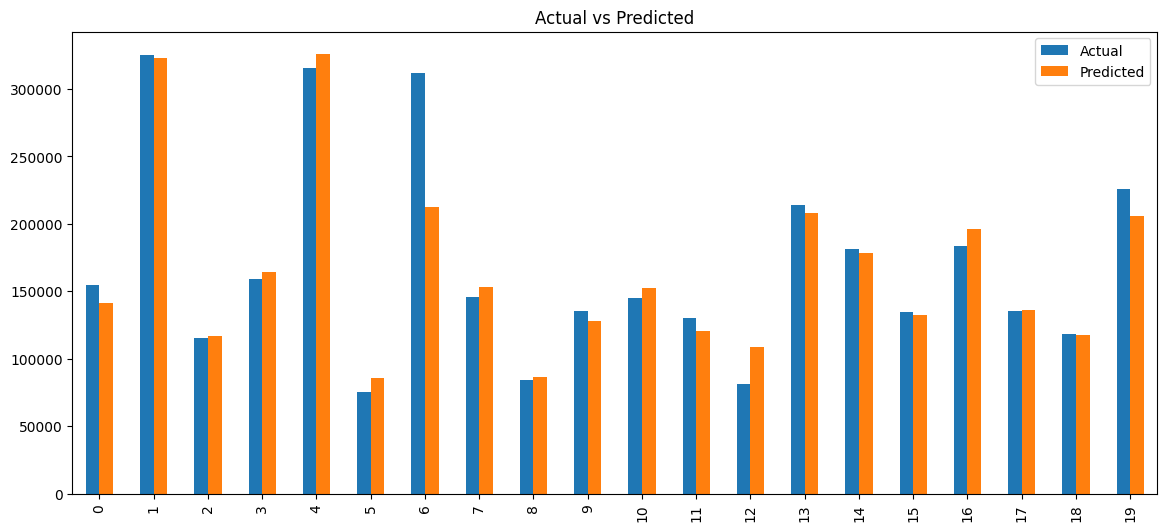

In [43]:
compare = compare.head(20)

compare.plot(
kind="bar",
figsize=(14,6)
)

plt.title("Actual vs Predicted")

plt.show()

Correlation with Target

In [44]:
corr = df.corr()

corr["SalePrice"].sort_values(ascending=False).head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64